# Exploring the Iris Dataset

roadmap.sh project: https://roadmap.sh/projects/exploring-iris-dataset

Load the classic Iris dataset (from Seaborn's built-in copy), check
class balance, look at univariate and bivariate distributions with
histograms/box plots/pairplot, compute a correlation heatmap, and
summarize what separates the three species.

## 1. Setup & load data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

iris = sns.load_dataset("iris")
iris.shape

(150, 5)

In [2]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


## 2. Class balance

Check how many rows belong to each of the three species.

In [4]:
species_counts = iris["species"].value_counts()
species_counts

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

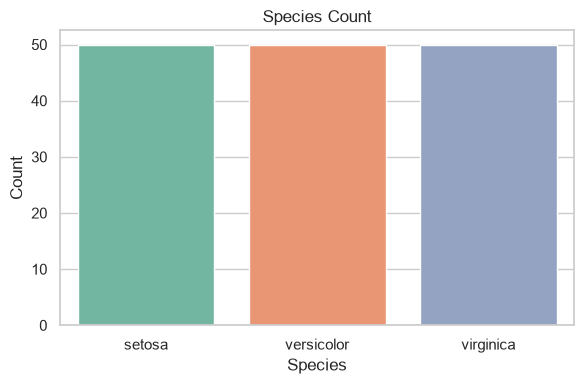

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=iris, x="species", hue="species",
              palette="Set2", legend=False, ax=ax)
ax.set_title("Species Count")
ax.set_xlabel("Species")
ax.set_ylabel("Count")
fig.tight_layout()
fig.savefig("outputs/species_balance.png", dpi=150)
plt.show()

The dataset is perfectly balanced: 50 rows for each of *setosa*,
*versicolor*, and *virginica*, so no resampling is needed before
further analysis.

## 3. Univariate distributions: histograms & box plots

One histogram and one box plot (split by species) per numerical
feature.

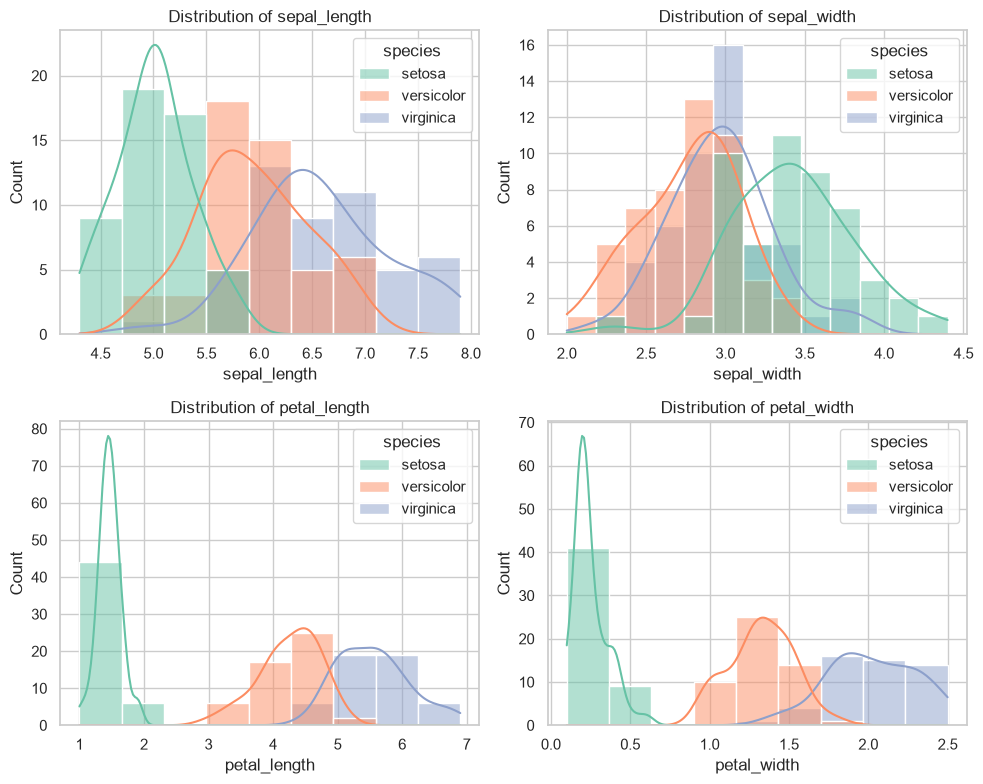

In [6]:
numeric_cols = iris.columns.drop("species")

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for col, ax in zip(numeric_cols, axes.flatten()):
    sns.histplot(data=iris, x=col, hue="species", kde=True,
                 palette="Set2", ax=ax)
    ax.set_title(f"Distribution of {col}")
fig.tight_layout()
fig.savefig("outputs/feature_histograms.png", dpi=150)
plt.show()

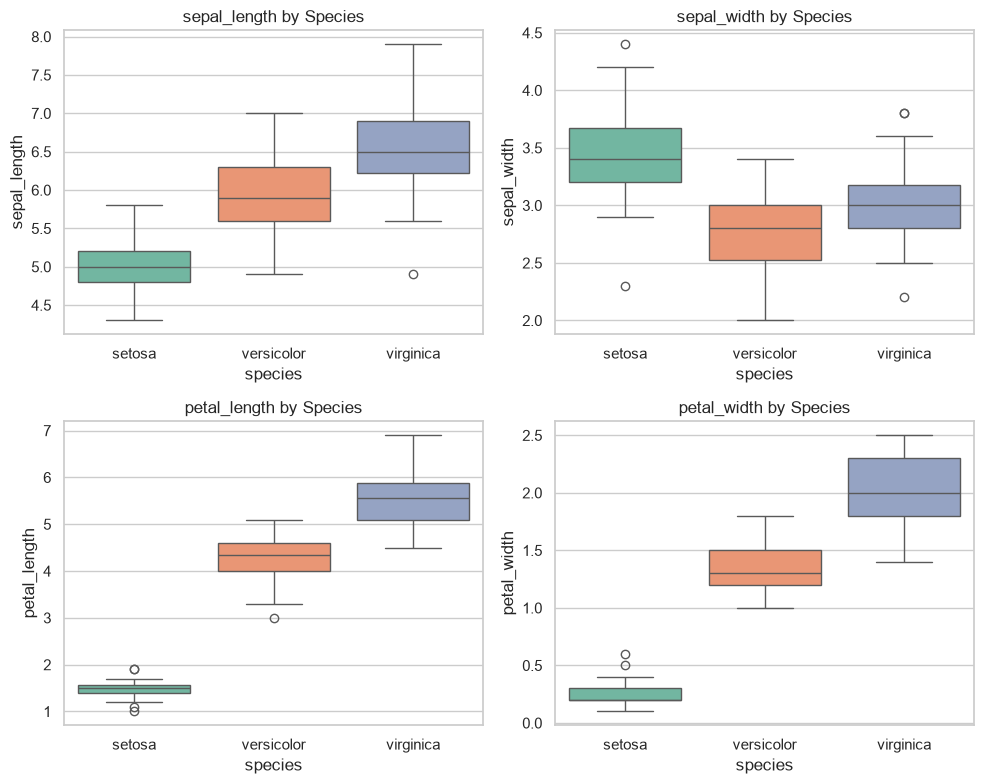

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for col, ax in zip(numeric_cols, axes.flatten()):
    sns.boxplot(data=iris, x="species", y=col, hue="species",
                palette="Set2", legend=False, ax=ax)
    ax.set_title(f"{col} by Species")
fig.tight_layout()
fig.savefig("outputs/feature_boxplots.png", dpi=150)
plt.show()

`petal_length` and `petal_width` show the cleanest separation between
species in both the histograms and the box plots -- *setosa* forms a
tight, non-overlapping cluster at low values, while *versicolor* and
*virginica* overlap more but still show a shift in medians.
`sepal_width` shows the most overlap across species.

## 4. Pairplot

Visualize relationships between all features at once, colored by
species.

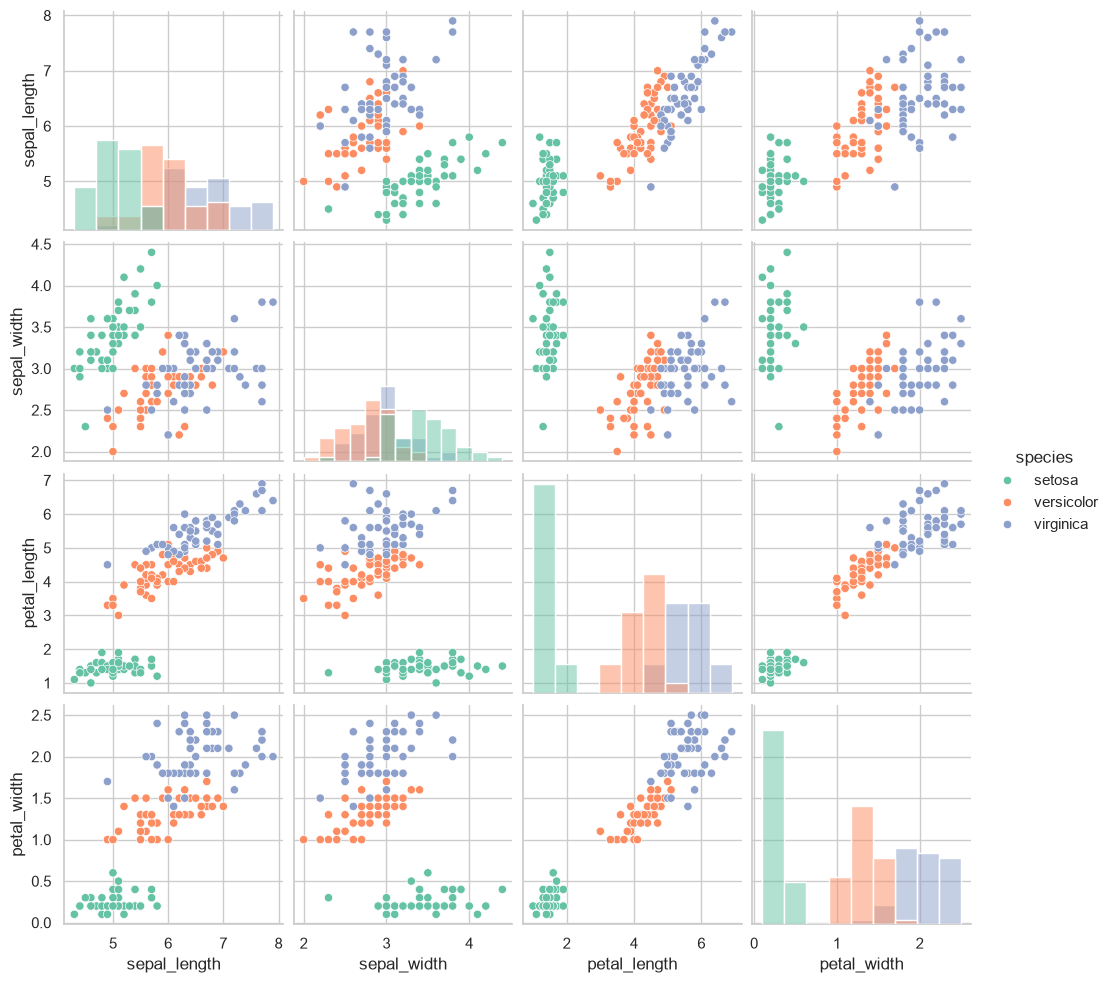

In [8]:
pairgrid = sns.pairplot(iris, hue="species", palette="Set2",
                         diag_kind="hist")
pairgrid.figure.savefig("outputs/pairplot.png", dpi=150)
plt.show()

The `petal_length` vs `petal_width` panel shows the three species as
almost linearly separable clusters -- a straight line could separate
*setosa* from the other two with zero error, and a second line
mostly separates *versicolor* from *virginica*. Any pairing that
includes `sepal_width` is the least separable.

## 5. Correlation heatmap

In [9]:
corr = iris[numeric_cols].corr()
corr

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


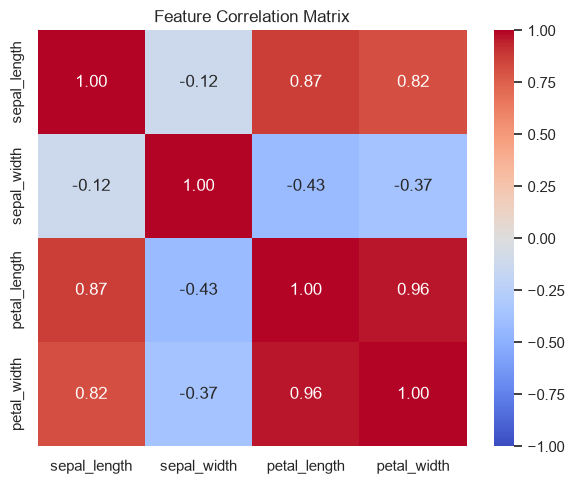

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, ax=ax)
ax.set_title("Feature Correlation Matrix")
fig.tight_layout()
fig.savefig("outputs/correlation_heatmap.png", dpi=150)
plt.show()

`petal_length` and `petal_width` are almost perfectly correlated
(0.96), and both correlate strongly with `sepal_length` (~0.87 and
0.82). `sepal_width` is the outlier, weakly *negatively* correlated
with the other three features.

## 6. Summary of findings

- The dataset is perfectly balanced (50 rows per species), so no
  class-imbalance correction is needed.
- **Petal measurements** (`petal_length`, `petal_width`) are far more
  discriminative than sepal measurements. *setosa* is linearly
  separable from the other two species on petal features alone.
- *versicolor* and *virginica* overlap on most features but remain
  distinguishable on petal length/width, with *virginica* skewing
  larger.
- `sepal_width` is the weakest predictor of species and is the only
  feature negatively correlated with the rest.
- The strong correlation between `petal_length` and `petal_width`
  (0.96) suggests one could largely substitute for the other in a
  simplified model.